In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import scipy
from scipy.linalg import sqrtm
import scipy.linalg as la
import time
from tqdm.notebook import tqdm 


In [2]:
#function
def gr_zinengr(E, H, T, T_dx, Nd):
    I_nd = np.eye(Nd, dtype=complex)
    
    Tmat = np.block([
        [np.linalg.inv(T) @ (E - H), -np.linalg.inv(T) @ T.conj().T],
        [I_nd, np.zeros((Nd, Nd), dtype=complex)]
    ])

    eigvals, eigvecs = np.linalg.eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    S1 = eigvecs[:Nd, :Nd] 
    S2 = eigvecs[Nd:, :Nd]  

    g = np.linalg.inv(E - H - T @ S1 @ np.linalg.inv(S2))
    
    # 计算自能 Sigma
    Sigma = T_dx.conj().T @ g @ T_dx
    Gamma = 1j * (Sigma - Sigma.conj().T)
    return Sigma, Gamma

def Green_device_1(Nd, N, E, H, V, Sigma_r, Sigma_l):
    ALR = E - H
    
    # Gnn (从右向左递归)
    Gnn = np.zeros((N, Nd, Nd), dtype=complex)
    Gnn[N-1] = np.linalg.inv(ALR - Sigma_r)  # N-1 对应最右侧格点
    for n in range(N-2, 0, -1):              
        Gnn[n] = np.linalg.inv(ALR - V @ Gnn[n+1] @ V.conj().T)
    Gnn[0] = np.linalg.inv(ALR - V @ Gnn[1] @ V.conj().T - Sigma_l)
    
    # G1n 
    G1n = Gnn[0].copy()
    for n in range(1, N):
        G1n = G1n @ V @ Gnn[n]
        
    # Gnn2 (从左向右递归)
    Gnn2 = np.zeros((N, Nd, Nd), dtype=complex)
    Gnn2[0] = np.linalg.inv(ALR - Sigma_l)
    for n in range(1, N-1):
        Gnn2[n] = np.linalg.inv(ALR - V.conj().T @ Gnn2[n-1] @ V)
    Gnn2[N-1] = np.linalg.inv(ALR - V.conj().T @ Gnn2[N-2] @ V - Sigma_r)
    
    # Gn1
    Gn1 = Gnn2[N-1].copy()
    for n in range(N-2, -1, -1):
        Gn1 = Gn1 @ V.conj().T @ Gnn2[n]

    #Gnn2[N-1] (右下角)，Gnn[0] (左上角)，G1n (右上角)，Gn1 (左下角)

    return Gnn, G1n, Gnn2, Gn1

def Scatter_NSN(Nd, N, Gamma_l, Gamma_r, G1n, Gnn, Gn1, Gnn2):
    """计算散射矩阵 S (对应原代码 Scatter_NSN，当前主循环中被注释)"""
    sq_Gamma_l = la.sqrtm(Gamma_l)
    sq_Gamma_r = la.sqrtm(Gamma_r)
    
    S_11 = -np.eye(N_dim) + 1j * sq_Gamma_l @ Gnn[0] @ sq_Gamma_l
    S_12 = 1j * sq_Gamma_l @ G1n @ sq_Gamma_r
    S_21 = 1j * sq_Gamma_r @ Gn1 @ sq_Gamma_l
    S_22 = -np.eye(N_dim) + 1j * sq_Gamma_r @ Gnn2[M-1] @ sq_Gamma_r
    
    S = np.block([
        [S_11, S_12],
        [S_21, S_22]
    ])
    return S

In [7]:
#来源
dela = 0.25 * 1e-3
chaodaojiao = 0
a=6.49 * 0.1
t =38 * dela
af =200 * 1e-4
mu = 4 * dela

#两边
hx=0    #0.5
hz=8 * dela #0.95
#(my = 0.954776)
Ul = -0.1 * t
saimanjiao = np.pi*0

#中间
mx=1.5 *np.sqrt(mu**2 + dela**2) #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0.5

T_Tc=1e-3
Delta = dela#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=int(np.floor(2 * 10**3 * 1 / a))
Nd=4
KBT=2 * dela * T_Tc / 3.5


#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao):
    if weizhi==1:
        Delta_X=np.zeros((2,2))
        HX_block=(Ul-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==2:
        Delta_X=Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= np.zeros((2,2))
        HX_block=(Ul-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(hx,hz,saimanjiao,1,chaodaojiao)
H_L_right_to_left_hop=H_hop(0)

#中间矩阵信息
H_center_to_L=H_hop(0)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao)
H_center_right_to_left_hop=H_hop(af)

H_R_to_center=H_hop(0)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao)
H_R_right_to_left_hop=H_hop(0)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop #2到1

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center


Calculating Energy Points:   0%|          | 0/101 [00:00<?, ?it/s]

Elapsed time: 6.82 seconds


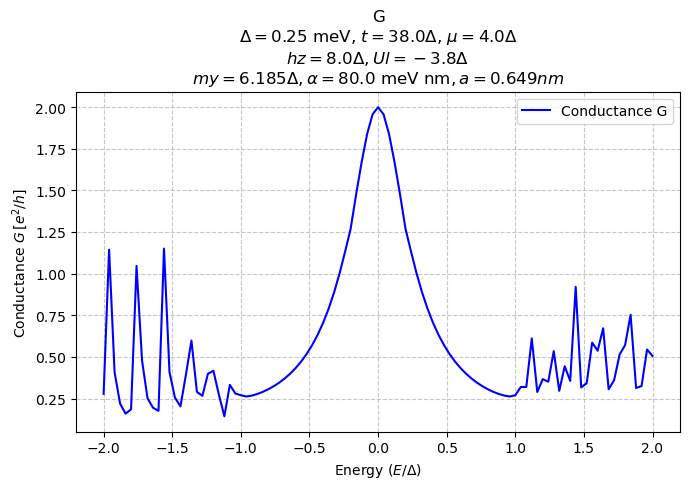

0.0015461646096066226


In [4]:
# 计时开始 #E变 T
start_time = time.time()
#N= 2 #
N=int(np.floor(2 * 10**3 * 1 / a))
Mdata = 101
Energy = np.linspace(-2, 2, Mdata)
G = np.zeros(Mdata, dtype=float)
Nd=4
# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * dela
    E_mat = (ep + 1j *1e-8) * np.eye(4, dtype=complex)

    # 计算电极格林函数
    Sigma_r, Gamma_r = gr_zinengr(E_mat, H_r,T_r, T_RD, Nd)
    Sigma_l, Gamma_l = gr_zinengr(E_mat, H_l,T_l, T_LD, Nd)
    #Sigma_r, Gamma_r = Green_lead_1(Nd, E_mat, H_r, T_r, T_RD)
    #Sigma_l, Gamma_l = Green_lead_1(Nd, E_mat, H_l, T_l, T_LD)

    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    Gamma_hh_r = Gamma_r[2:4, 2:4]
    

    Gnn, G1n, Gnn2, Gn1 = Green_device_1(Nd, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)
    
    # 提取末端格林函数 (索引改为 N-1)
    GNN = Gnn2[N-1]

    GLR_ee = G1n[0:2, 0:2]
    GLR_eh = G1n[0:2, 2:4]
    GRR_eh = GNN[0:2, 2:4]
    
    # 计算各个过程的透射率
    Tee = np.real(np.trace(Gamma_ee_l @ GLR_ee @ Gamma_ee_r @ GLR_ee.conj().T))
    T_CAR = np.real(np.trace(Gamma_ee_l @ GLR_eh @ Gamma_hh_r @ GLR_eh.conj().T))
    T_LAR = np.real(np.trace(Gamma_ee_r @ GRR_eh @ Gamma_hh_r @ GRR_eh.conj().T))
    
    # 最终电导计算
    G[n] = (Tee + T_CAR + 2 * T_LAR) 

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")



plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel(r'Conductance $G \, [e^2/h]$')
plt.title(
    fr'G' + '\n' +
    fr'$\Delta = {0.25}$ meV, $t = {t/dela }\Delta$, $\mu = {mu/dela}\Delta$' + '\n' +
    fr'$hz = {hz/dela}\Delta, Ul={Ul/dela}\Delta$' + '\n' +
    fr'$my = {mx/dela:.3f}\Delta, \alpha = {af/dela}\text{{ meV nm}}, a={0.649}nm$'
)


plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
#plt.ylim(-0.1,1.1)
plt.show()


print(mx)

In [9]:
#来源 NS
dela = 0.25# * 1e-3
chaodaojiao = 0
a=6.49 * 0.1
t =38 * dela
af =80*dela
mu = 4 * dela

#两边
hx=0    #0.5
hz=8 * dela #0.95
#(my = 0.954776)
Ul = -0.1 * t
saimanjiao = np.pi*0
 
#中间
mx=1.5 *np.sqrt(mu**2 + dela**2) #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0.5

T_Tc=1e-3
Delta = dela#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=int(np.floor(2 * 10**3 * 1 / a))
Nd=4
KBT=2 * dela * T_Tc / 3.5


#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao):
    if weizhi==1:
        Delta_X=np.zeros((2,2))
        HX_block=(Ul-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==2:
        Delta_X=Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= np.zeros((2,2))
        HX_block=(Ul-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(hx,hz,saimanjiao,1,chaodaojiao)
H_L_right_to_left_hop=H_hop(0)

#中间矩阵信息
H_center_to_L=H_hop(0)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao)
H_center_right_to_left_hop=H_hop(af)

H_R_to_center=H_hop(af)

#右边矩阵信息
H_R_onsite=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao)
H_R_right_to_left_hop=H_hop(af)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop #2到1

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center


Calculating Energy Points:   0%|          | 0/301 [00:00<?, ?it/s]

Elapsed time: 6.93 seconds


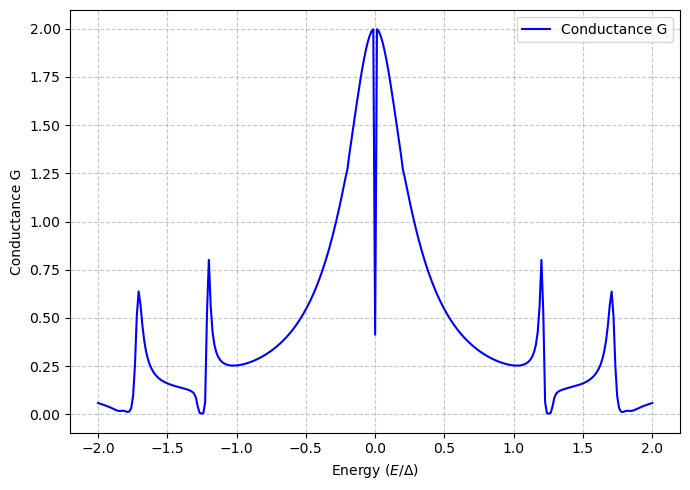

In [10]:
# 计时开始 #E变 R
start_time = time.time()
#N= 2 #
N=1000#int(np.floor(2 * 10**3 * 1 / a))
Mdata = 301
Energy = np.linspace(-2, 2, Mdata)
#Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)
Nd=4
# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * dela
    E_mat = (ep + 1j *1e-8) * np.eye(4, dtype=complex)

    # 计算电极格林函数
    Sigma_r, Gamma_r = gr_zinengr(E_mat, H_r,T_r, T_RD, Nd)
    Sigma_l, Gamma_l = gr_zinengr(E_mat, H_l,T_l, T_LD, Nd)
    #Sigma_r, Gamma_r = Green_lead_1(Nd, E_mat, H_r, T_r, T_RD)
    #Sigma_l, Gamma_l = Green_lead_1(Nd, E_mat, H_l, T_l, T_LD)

    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    Gamma_hh_r = Gamma_r[2:4, 2:4]

    sqrt_Gamma_ee_l = scipy.linalg.sqrtm(Gamma_ee_l)
    sqrt_Gamma_hh_l = scipy.linalg.sqrtm(Gamma_hh_l)

    Gnn, G1n, Gnn2, Gn1 = Green_device_1(Nd, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)
    
  # 提取首端格林函数
    GLL = Gnn[0]
    GLL_ee = GLL[0:2, 0:2]
    GLL_he = GLL[2:4, 0:2]
    
    # 5. 计算散射矩阵元
    S_LL_ee = -1 * np.eye(2) + 1j * sqrt_Gamma_ee_l @ GLL_ee @ sqrt_Gamma_ee_l
    S_LL_he = 1j * sqrt_Gamma_hh_l @ GLL_he @ sqrt_Gamma_ee_l

    # 6. 计算反射概率 (核心修复：R_he 矩阵乘法修正)
    R_ee = np.real(np.trace(S_LL_ee.conj().T @ S_LL_ee))
    R_he = np.real(np.trace(S_LL_he.conj().T @ S_LL_he)) # <--- 修正了原来的 S_LL_ee

    # 7. 最终电导计算 (固定入射通道数 N=2)
    G[n] = 2 - R_ee + R_he

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")



plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel('Conductance G')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
#plt.ylim(-0.1,1.1)
plt.show()



In [ ]:
#参数 SNS 我的
dela = 1
chaodaojiao = 0
m=2.5*10**(-3)
a=1
t =1/(2*m*a**2)
af =50
mu = 0

#两边
hx=4   #0.5
hz=0.5 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0

#中间
mx=-10 #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0
af2=0
U_c=0

T_Tc=1e-4
Delta = dela* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=2
q=0
dianshubei=0.2#8
KBT=2 * dela * T_Tc / 3.5
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy #-1 ?
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==2:
        Delta_X=np.zeros((2,2))
        HX_block=(U_c-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(hx,hz,saimanjiao,1,chaodaojiao)
H_L_right_to_left_hop=H_hop(af)

#中间矩阵信息
H_center_to_L=H_hop(0)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao)
H_center_right_to_left_hop=H_hop(af2*af)

H_R_to_center=H_hop(0)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao)
H_R_right_to_left_hop=H_hop(af)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center




In [10]:
#参数 NS 我的
dela = 1
chaodaojiao = 0
a=1
t =200
af =70
mu = 0

#左边
hx=4   #0.5
hz=0 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0

#右边
mx=0.9 #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0
af2=0
U_c=0

Delta = dela#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))


#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao,renyixiang=0):
    if weizhi==2:
        Delta_X=np.zeros((2,2))
        HX_block=(U_c-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao)
H_L_right_to_left_hop=H_hop(af2*af,t)

#中间矩阵信息
H_center_to_L=H_hop(af2*af,t)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao)
H_center_right_to_left_hop=H_hop(af2*af,t)

H_R_to_center=H_hop(0,t*0.8)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao,t)
H_R_right_to_left_hop=H_hop(af,t)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center




Calculating Energy Points:   0%|          | 0/301 [00:00<?, ?it/s]

Elapsed time: 5.56 seconds


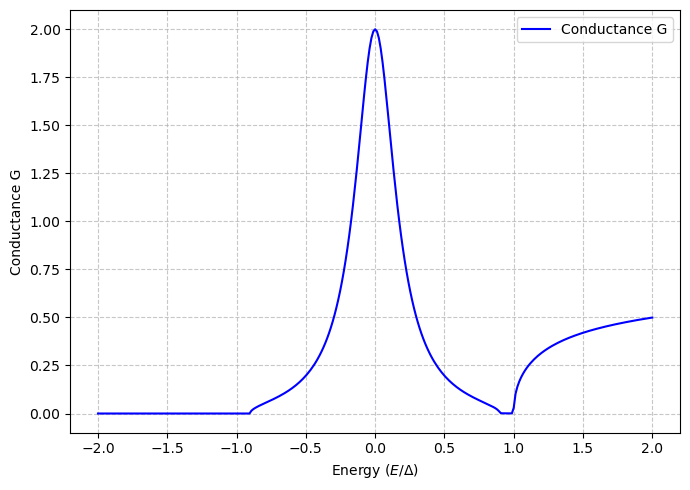

In [11]:
# 计时开始 #E变 R
start_time = time.time()
#N= 2 #
N=1000#int(np.floor(2 * 10**3 * 1 / a))
Mdata = 301
Energy = np.linspace(-2, 2, Mdata)
#Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)
Nd=4
# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * dela
    E_mat = (ep + 1j *1e-6) * np.eye(4, dtype=complex)

    # 计算电极格林函数
    Sigma_r, Gamma_r = gr_zinengr(E_mat, H_r,T_r, T_RD, Nd)
    Sigma_l, Gamma_l = gr_zinengr(E_mat, H_l,T_l, T_LD, Nd)
    #Sigma_r, Gamma_r = Green_lead_1(Nd, E_mat, H_r, T_r, T_RD)
    #Sigma_l, Gamma_l = Green_lead_1(Nd, E_mat, H_l, T_l, T_LD)

    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    Gamma_hh_r = Gamma_r[2:4, 2:4]

    sqrt_Gamma_ee_l = scipy.linalg.sqrtm(Gamma_ee_l)
    sqrt_Gamma_hh_l = scipy.linalg.sqrtm(Gamma_hh_l)

    Gnn, G1n, Gnn2, Gn1 = Green_device_1(Nd, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)
    
  # 提取首端格林函数
    GLL = Gnn[0]
    GLL_ee = GLL[0:2, 0:2]
    GLL_he = GLL[2:4, 0:2]
    
    # 5. 计算散射矩阵元
    S_LL_ee = -1 * np.eye(2) + 1j * sqrt_Gamma_ee_l @ GLL_ee @ sqrt_Gamma_ee_l
    S_LL_he = 1j * sqrt_Gamma_hh_l @ GLL_he @ sqrt_Gamma_ee_l

    # 6. 计算反射概率 (核心修复：R_he 矩阵乘法修正)
    R_ee = np.real(np.trace(S_LL_ee.conj().T @ S_LL_ee))
    R_he = np.real(np.trace(S_LL_he.conj().T @ S_LL_he)) # <--- 修正了原来的 S_LL_ee

    # 7. 最终电导计算 (固定入射通道数 N=2)
    G[n] = 2 - R_ee + R_he

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")



plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel('Conductance G')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
#plt.ylim(-0.1,1.1)
plt.show()

